# Modélisation ML — Flood Prediction
**Projet M**  
Phase 6 & 9 : Apprentissage Supervisé + Évaluation des Modèles

---

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

print(' Bibliothèques importées')

 Bibliothèques importées


## 2. Chargement & Préparation des données

In [2]:
df = pd.read_csv('train.csv')

# Séparation features / cible (on retire 'id' inutile)
features = [c for c in df.columns if c not in ['id', 'FloodProbability']]
X = df[features]
y = df['FloodProbability']

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dataset : {df.shape[0]:,} lignes × {len(features)} features')
print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')

Dataset : 1,117,957 lignes × 20 features
X_train : (894365, 20) | X_test : (223592, 20)


## 3. Fonction d'évaluation

On crée une fonction réutilisable qui calcule nos 3 métriques clés :
- **R²** : proportion de variance expliquée (plus proche de 1 = meilleur)
- **MAE** : erreur absolue moyenne (en unités de FloodProbability)
- **RMSE** : racine de l'erreur quadratique moyenne (pénalise les grandes erreurs)

In [3]:
def evaluer_modele(nom, modele, X_train, X_test, y_train, y_test):
    """Entraîne et évalue un modèle, retourne ses métriques."""
    t0 = time.time()
    modele.fit(X_train, y_train)
    duree = round(time.time() - t0, 2)
    
    pred_train = modele.predict(X_train)
    pred_test  = modele.predict(X_test)
    
    r2_train = r2_score(y_train, pred_train)
    r2_test  = r2_score(y_test, pred_test)
    mae      = mean_absolute_error(y_test, pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, pred_test))
    
    print(f' {nom}')
    print(f'   R² train : {r2_train:.4f} | R² test : {r2_test:.4f}')
    print(f'   MAE      : {mae:.4f}    | RMSE    : {rmse:.4f}')
    print(f'   Temps    : {duree}s')
    print()
    
    return {
        'modele': modele,
        'predictions': pred_test,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'MAE': mae,
        'RMSE': rmse,
        'temps': duree
    }

resultats = {}
print('Fonction d\'évaluation prête ')

Fonction d'évaluation prête 


## 4. Modèle 1 — Régression Ridge (L2)

La régression Ridge ajoute une **pénalité L2** pour éviter le surapprentissage.  
Elle minimise : `||y - Xβ||² + α||β||²`

 Ridge (L2)
   R² train : 0.8450 | R² test : 0.8449
   MAE      : 0.0158    | RMSE    : 0.0201
   Temps    : 0.31s



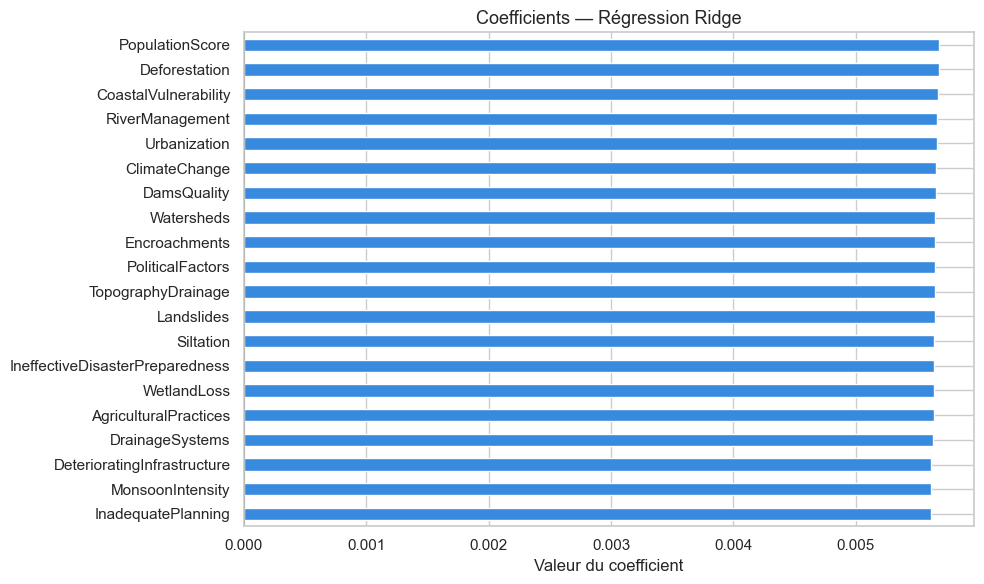

 Les coefficients sont tous positifs et similaires → chaque variable contribue également.


In [4]:
ridge = Ridge(alpha=1.0)
resultats['Ridge (L2)'] = evaluer_modele('Ridge (L2)', ridge, X_train, X_test, y_train, y_test)

# Visualiser les coefficients
coef_ridge = pd.Series(ridge.coef_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
coef_ridge.plot(kind='barh', ax=ax, color='#378ADD', edgecolor='white')
ax.set_title('Coefficients — Régression Ridge')
ax.set_xlabel('Valeur du coefficient')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('plot_ridge_coef.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Les coefficients sont tous positifs et similaires → chaque variable contribue également.')

## 5. Modèle 2 — Régression Lasso (L1)

Le Lasso ajoute une **pénalité L1** qui peut forcer certains coefficients à **zéro** (sélection automatique de variables).  
Il minimise : `||y - Xβ||² + α||β||₁`

In [5]:
lasso = Lasso(alpha=0.0001)
resultats['Lasso (L1)'] = evaluer_modele('Lasso (L1)', lasso, X_train, X_test, y_train, y_test)

# Variables éliminées par Lasso
coef_lasso = pd.Series(lasso.coef_, index=features)
variables_zero = coef_lasso[coef_lasso == 0]
print(f'Variables mises à zéro par Lasso : {len(variables_zero)}')
if len(variables_zero) > 0:
    print(variables_zero)
else:
    print(' Lasso conserve toutes les variables (alpha faible)')

 Lasso (L1)
   R² train : 0.8449 | R² test : 0.8449
   MAE      : 0.0158    | RMSE    : 0.0201
   Temps    : 0.29s

Variables mises à zéro par Lasso : 0
 Lasso conserve toutes les variables (alpha faible)


## 6. Modèle 3 — Gradient Boosting (GBM)

Le Gradient Boosting construit des **arbres de décision en séquence**, chaque arbre corrigeant les erreurs du précédent.  
C'est un modèle très puissant mais plus lent à entraîner.

> ⏳ Ce modèle peut prendre quelques minutes sur le dataset complet.

 Gradient Boosting
   R² train : 0.6868 | R² test : 0.6832
   MAE      : 0.0236    | RMSE    : 0.0287
   Temps    : 223.81s



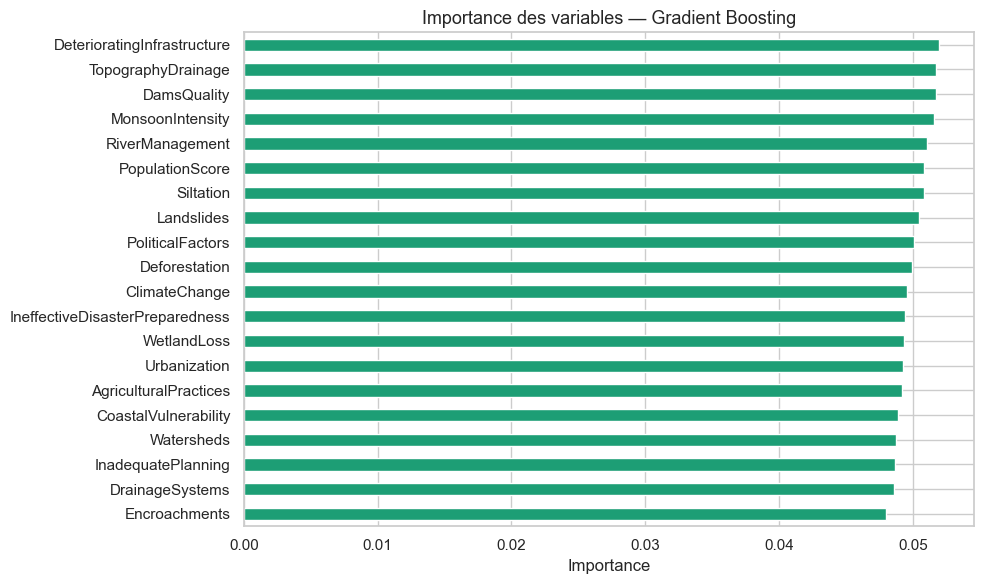

In [6]:
gbm = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
resultats['Gradient Boosting'] = evaluer_modele('Gradient Boosting', gbm, X_train, X_test, y_train, y_test)

# Feature Importance GBM
fi_gbm = pd.Series(gbm.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
fi_gbm.plot(kind='barh', ax=ax, color='#1D9E75', edgecolor='white')
ax.set_title('Importance des variables — Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plot_gbm_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparaison des modèles

In [8]:
# Tableau comparatif
tableau = pd.DataFrame({
    nom: {
        'R² Train': round(r['R2_train'], 4),
        'R² Test' : round(r['R2_test'], 4),
        'MAE'     : round(r['MAE'], 4),
        'RMSE'    : round(r['RMSE'], 4),
        'Temps(s)': r['temps']
    }
    for nom, r in resultats.items()
}).T

print('=== COMPARAISON DES MODÈLES ===')
print(tableau.to_string())
print(f"\n Meilleur R² test : {tableau['R² Test'].idxmax()} ({tableau['R² Test'].max():.4f})")
print(f" Plus rapide       : {tableau['Temps(s)'].idxmin()} ({tableau['Temps(s)'].min()}s)")

=== COMPARAISON DES MODÈLES ===
                   R² Train  R² Test     MAE    RMSE  Temps(s)
Ridge (L2)           0.8450   0.8449  0.0158  0.0201      0.31
Lasso (L1)           0.8449   0.8449  0.0158  0.0201      0.29
Gradient Boosting    0.6868   0.6832  0.0236  0.0287    223.81

 Meilleur R² test : Ridge (L2) (0.8449)
 Plus rapide       : Lasso (L1) (0.29s)


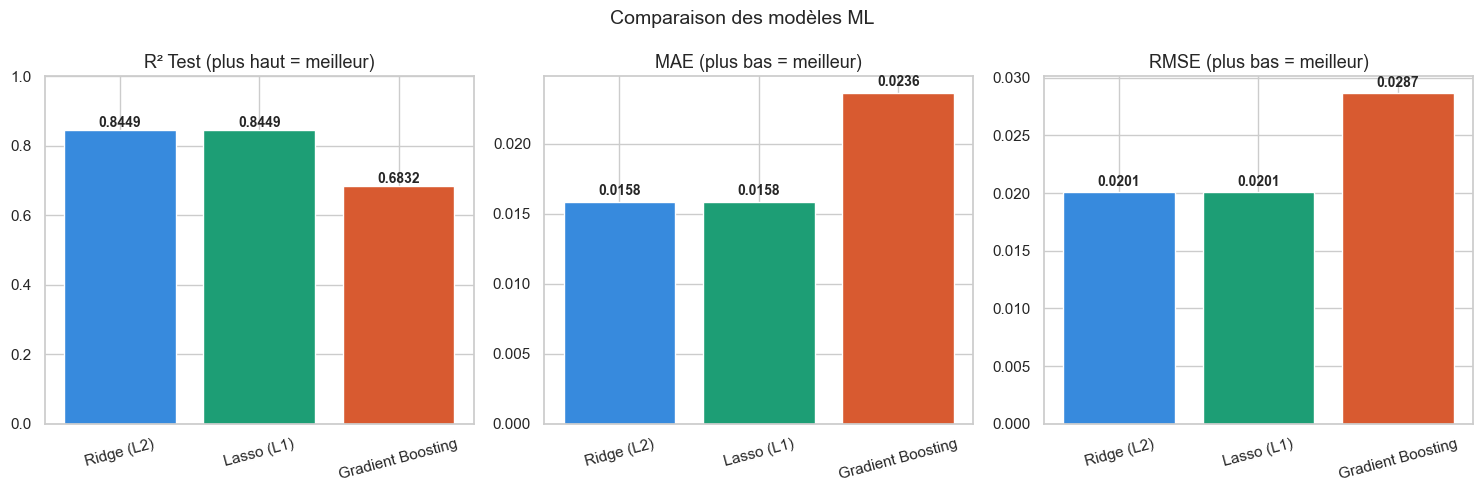

In [9]:
# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noms  = list(resultats.keys())
r2s   = [resultats[n]['R2_test'] for n in noms]
maes  = [resultats[n]['MAE'] for n in noms]
rmses = [resultats[n]['RMSE'] for n in noms]
colors = ['#378ADD', '#1D9E75', '#D85A30']

axes[0].bar(noms, r2s, color=colors, edgecolor='white')
axes[0].set_title('R² Test (plus haut = meilleur)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2s):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(noms, maes, color=colors, edgecolor='white')
axes[1].set_title('MAE (plus bas = meilleur)')
for i, v in enumerate(maes):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(noms, rmses, color=colors, edgecolor='white')
axes[2].set_title('RMSE (plus bas = meilleur)')
for i, v in enumerate(rmses):
    axes[2].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Comparaison des modèles ML', fontsize=14)
plt.tight_layout()
plt.savefig('plot_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analyse des résidus — Meilleur modèle

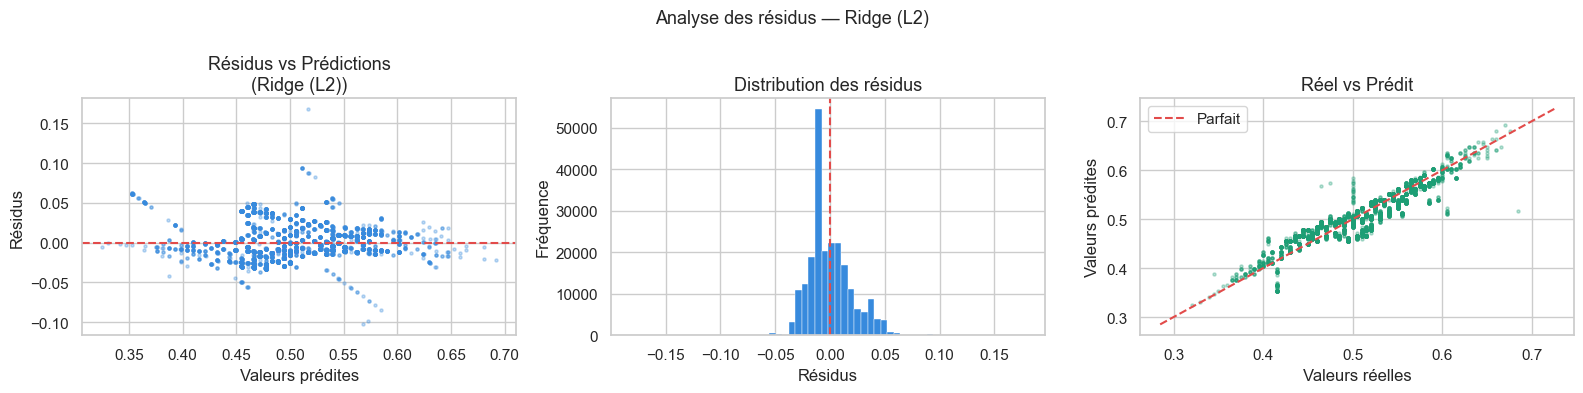

Résidus (Ridge (L2)) :
  Moyenne  : 0.000026 (proche de 0 = bon signe)
  Écart-type : 0.0201
  Dans ±0.05 : 98.4% des prédictions
  Dans ±0.02 : 73.6% des prédictions


In [10]:
# Analyse du meilleur modèle (Ridge)
best_name = max(resultats, key=lambda n: resultats[n]['R2_test'])
pred_best = resultats[best_name]['predictions']
residus   = y_test.values - pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Résidus vs valeurs prédites
axes[0].scatter(pred_best[:5000], residus[:5000], alpha=0.3, s=5, color='#378ADD')
axes[0].axhline(0, color='#E24B4A', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title(f'Résidus vs Prédictions\n({best_name})')

# Distribution des résidus
axes[1].hist(residus, bins=60, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Résidus')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

# Valeurs réelles vs prédites
axes[2].scatter(y_test.values[:5000], pred_best[:5000], alpha=0.3, s=5, color='#1D9E75')
lim = [y_test.min(), y_test.max()]
axes[2].plot(lim, lim, color='#E24B4A', linewidth=1.5, linestyle='--', label='Parfait')
axes[2].set_xlabel('Valeurs réelles')
axes[2].set_ylabel('Valeurs prédites')
axes[2].set_title('Réel vs Prédit')
axes[2].legend()

plt.suptitle(f'Analyse des résidus — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('plot_residus.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Résidus ({best_name}) :')
print(f'  Moyenne  : {residus.mean():.6f} (proche de 0 = bon signe)')
print(f'  Écart-type : {residus.std():.4f}')
print(f'  Dans ±0.05 : {(np.abs(residus) < 0.05).mean()*100:.1f}% des prédictions')
print(f'  Dans ±0.02 : {(np.abs(residus) < 0.02).mean()*100:.1f}% des prédictions')

## 9. Validation croisée (K-Fold)

La **validation croisée K-Fold** divise les données en K groupes et entraîne le modèle K fois.  
Elle donne une estimation plus fiable de la performance réelle du modèle.

=== VALIDATION CROISÉE 5-FOLD — Ridge ===
Scores R² par fold : [np.float64(0.8496), np.float64(0.8443), np.float64(0.8451), np.float64(0.8444), np.float64(0.8431)]
Moyenne  : 0.8453
Écart-type : 0.0022

 Un écart-type faible confirme que le modèle est stable.


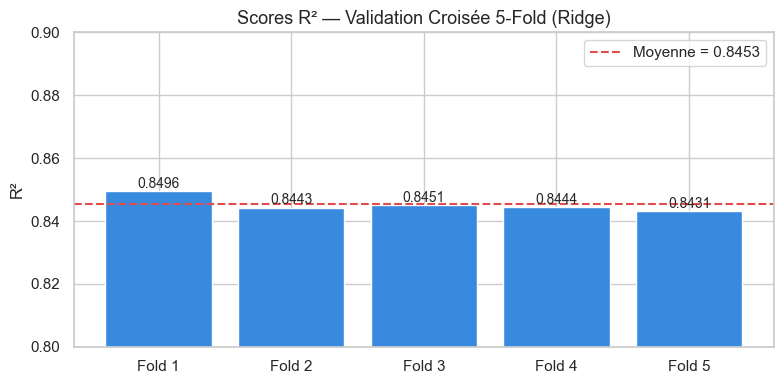

In [ ]:
from sklearn.model_selection import KFold

# On utilise un sous-ensemble pour la vitesse
X_cv = X.sample(n=100000, random_state=42)
y_cv = y[X_cv.index]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv = Ridge(alpha=1.0)

scores = cross_val_score(ridge_cv, X_cv, y_cv, cv=kf, scoring='r2', n_jobs=-1)

print(' VALIDATION CROISÉE 5-FOLD — Ridge')
print(f'Scores R² par fold : {[round(s, 4) for s in scores]}')
print(f'Moyenne  : {scores.mean():.4f}')
print(f'Écart-type : {scores.std():.4f}')
print()
print(' Un écart-type faible confirme que le modèle est stable.')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Fold {i+1}' for i in range(5)], scores, color='#378ADD', edgecolor='white')
ax.axhline(scores.mean(), color='#E24B4A', linestyle='--', label=f'Moyenne = {scores.mean():.4f}')
ax.set_title('Scores R² — Validation Croisée 5-Fold (Ridge)')
ax.set_ylabel('R²')
ax.set_ylim(0.8, 0.9)
ax.legend()
for i, v in enumerate(scores):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_kfold.png', dpi=150, bbox_inches='tight')
plt.show()